# BAYESIAN INFERENCE 

Model: $$y=x^3+\epsilon$$ where $\epsilon$ is noise (mean zero and variance 1) $\mathcal{N}(0,1)$. 

Suppose you are interested in an unknown x (scalar) and the prior is a Gaussian pdf with mean zero and variance 1 . 

$$ p(x) \propto \exp(-\frac{x^2}{2})$$

The likelihood (How likely it is to get y, given x) is simply proportional to the noise when we think about it:

$$ p(y|x) \propto \exp(-\frac{(y-x^3)^2}{2}) $$

However, we can also prove it: 
### Probability Density Function of a Normal Distribution

The probability density function of a **Normal (Gaussian) distribution** \(\mathcal{N}(\mu, \sigma^2)\) for a random variable \( z \) is:

$$
p(z) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{(z - \mu)^2}{2\sigma^2} \right)
$$

where:
- $(\mu)$ is the **mean** (location parameter),
- $(\sigma^2)$ is the **variance** (scale parameter),
- $(\sigma)$ is the **standard deviation**.


The posterior is therefore  $$ p(x|y) \propto p(x)p(y|x)\propto \exp (-\frac{(y-x^3)^2+x^2}{2} )$$

The weights are qual to the likelihood. 

Finally we normalize the weights. 

$$ w_i= \hat{w_i}/\sum_j^n \hat{w_j} $$

The weighted samples  $$\{x_i, w_i\}$$ are approximately distributed according to the posterior distribution. 

Now suppose we ran experiments and got a data : $$y=-2$$


Let's plot a histogram of n=1000 samples from the proposal distribution (green), with historgram of the associated weighted samples (orange), on top.

Using this value of $y$, $$E[x|y]=-0.69$$



Posterior mean E[x | y=-2] ≈ -0.69301


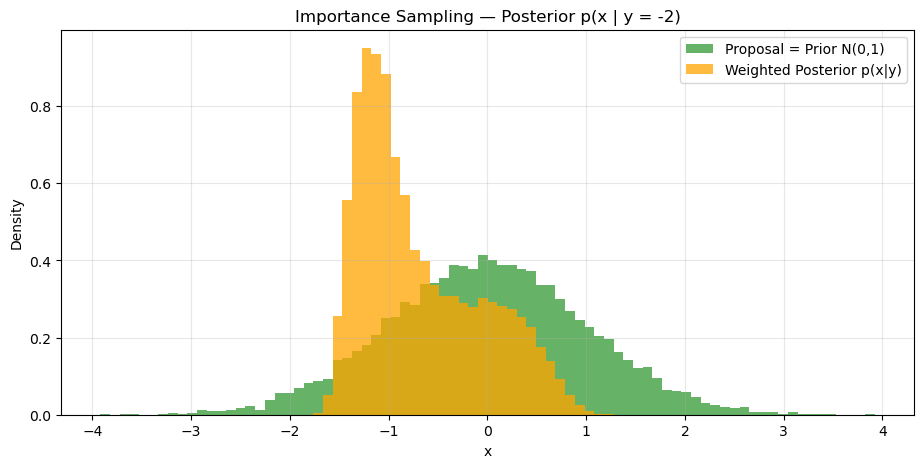

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ================== SETTINGS ==================
np.random.seed(42)
y_obs = -2                # ← Change this to your observed y
n_samples = 10000
# =============================================

# 1. Draw samples from proposal = prior ~ N(0,1)
x_samples = np.random.normal(loc=0, scale=1, size=n_samples)

# 2. Unnormalized weights = likelihood p(y|x)
weights_unnorm = np.exp(-0.5 * (y_obs - x_samples**3)**2)

# 3. Normalize weights
weights = weights_unnorm / np.sum(weights_unnorm)

# 4. Posterior mean via importance sampling
posterior_mean = np.average(x_samples, weights=weights)
print(f"Posterior mean E[x | y={y_obs}] ≈ {posterior_mean:.5f}")


# ================== PLOTS ==================
plt.figure(figsize=(11, 5))

# Proposal (green)
plt.hist(x_samples, bins=80, density=True, alpha=0.6, color='green', label='Proposal = Prior N(0,1)')

# Weighted posterior (orange)
plt.hist(x_samples, bins=80, density=True, weights=weights, alpha=0.75, color='orange', 
         label='Weighted Posterior p(x|y)')

plt.title(f'Importance Sampling — Posterior p(x | y = {y_obs})')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()